In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np

import matplotlib.pyplot as plt

1. İlk önce her karaktere karşılık gelen 8 bitlik karakter tanımlarını ayarlamak gerek. (İlk Braille Alfabesi'nden etkilendim)
2. Sonrada bir temel kelime uzunluğu belirleyip, sanırım 70 karakterini belirleyeceğim. 
3. Her kelimeyinin karşılığı olan 8 bitlik karakteri alacağız. 
4. Bunları bir matrise çevireceğin. 
5. Bu matrise positional encoding'i uygylayacağız ve elimizde özellik matrisi olacak.


In [8]:
max_seq_len = 70 # Maximum kelime uzunluğu
bit_depth = 8 # Her karakteri temsil eden dizinin uzunluğu.
exam_seq = "Merhaba" # Örnek kelime.


In [ ]:
# karakterlerin 8 bitlik tanımlarının yapılması
vocab = (
     ['<PAD>',   # padding (sequence equalization)
     '<UNK>',   # bilinmeyen karakter
     '<BOS>',   # beginning of sentence
     '<EOS>',   # end of sentence
     '<MASK>',  # masking (BERT tarzı)
     ' '] +      # boşluk (space)
    
    list('abcçdefgğhıijklmnoöprsştuüvyz') +
    list('ABCÇDEFGĞHIİJKLMNOÖPRSŞTUÜVYZ') +
    list('0123456789') +
    
    ['.',',',';',':','?','!','"',"'",'(',')','[',']','{','}','-','–','—','…','/','\\','|'] +
    
    ['\n']
)

char_dic = {}
for i in range(0, len(vocab) - 1):
    bits = [int(b) for b in format(i, '08b')]
    print(f"{i} -> {bits}")
    char_dic[vocab[i]] = bits


char_dic


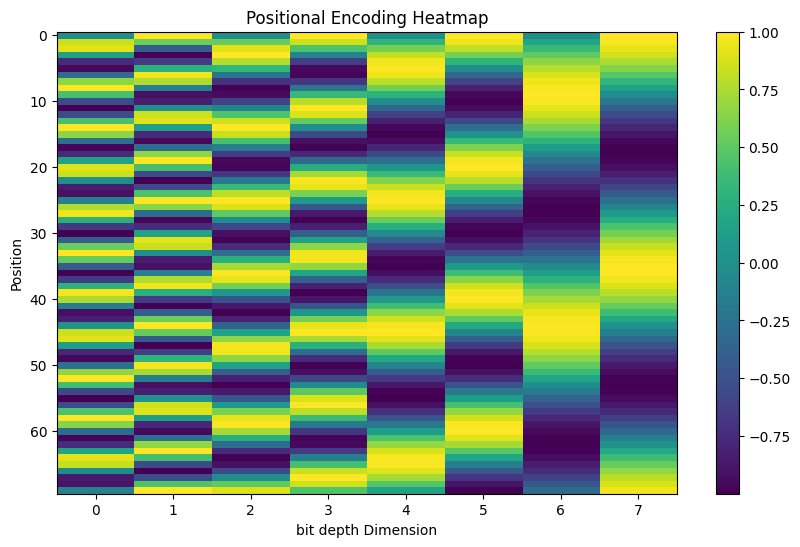

In [12]:
def plot_positional_encoding(pe):
    """
    Positional encoding matrisini görselleştirir
    """
    plt.figure(figsize=(10, 6))
    plt.imshow(pe, aspect='auto', cmap='viridis')
    plt.colorbar()
    plt.title("Positional Encoding Heatmap")
    plt.xlabel("bit depth Dimension")
    plt.ylabel("Position")
    plt.show()

def get_angle(pos, i, d_model):
    """
    Pozisyon ve boyut indeksine göre açı değerini hesaplar
    """
    return pos / (10 ** ((2 * (i // 2)) / d_model))


def positional_encoding_matrix(vocab_len, bit_depth):
    """
    Tüm positional encoding matrisini oluşturur
    """
    PE = np.ones((vocab_len, bit_depth))

    for pos in range(vocab_len):
        for i in range(bit_depth):
            angle = get_angle(pos, i, bit_depth)
            if i % 2 == 0:
                PE[pos, i] = np.sin(angle)
            else:
                PE[pos, i] = np.cos(angle)

    return PE

positional_information = positional_encoding_matrix(max_seq_len, bit_depth)

plot_positional_encoding(positional_information)



In [ ]:
# 70 x 8 boyutunda kelime matrisi olacak elimde. 
# Yani 560 boyutunda bir girdi alan bir şey lazım. 
# çıktı olarak dil modellerinin ihtiyacı olan 512'yi tercih edebilirim.

class TestModel(nn.Module):
    def __init__(self):
        self.linear1 = nn.Linear(560, 1024)
        self.linear2 = nn.Linear(1024, 1024)
        self.linear3 = nn.Linear(1024, 512)
        self.relu = nn.ReLU()
        pass

    def forward(self, vocab_matrix):
        arr = np.asarray(vocab_matrix).reshape(-1)

        x = self.linear1(arr)
        x = self.relu(x)
        x = self.linear2(x)
        x = self.relu(x)
        x = self.linear3(x)
        x = self.relu(x)

        return x

In [ ]:
# Modeli eğitme aşamsı

model = TestModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

X = torch.rand(64, 100) # 100 tane özellikli 64 örnek. Aslında bizim senaryoda 70 * 8 tane özellik olacak. 
y = torch.randint(0, 10, (64,))  # 10 sınıf


epochs = 10

for epoch in range(epochs):

    model.train() # Modeli eğitime hazırlıyor.

    outputs = model(X)

    loss = criterion(outputs, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch + 1}, Loss {loss.item():.4f}")





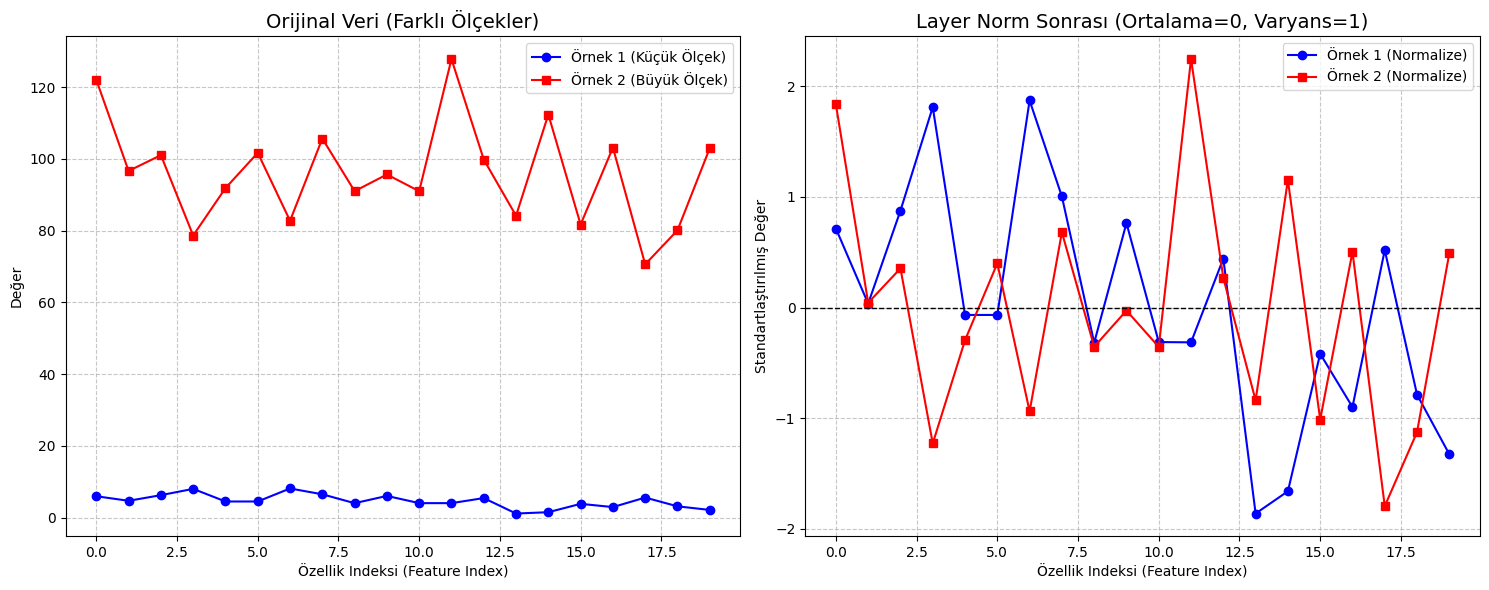

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def layer_norm(x, eps=1e-5):
    # x: (batch_size, features)
    mean = np.mean(x, axis=-1, keepdims=True)
    var = np.var(x, axis=-1, keepdims=True)
    return (x - mean) / np.sqrt(var + eps)

# 1. Farklı ölçeklerde veri oluşturma
# Örnek 1: Düşük değerler (0-10 arası)
# Örnek 2: Yüksek değerler (100-110 arası)
np.random.seed(42)
sample1 = np.random.normal(loc=5, scale=2, size=20)
sample2 = np.random.normal(loc=100, scale=15, size=20)
data = np.vstack([sample1, sample2])

# 2. Layer Norm Uygulama
normalized_data = layer_norm(data)

# 3. Görselleştirme
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Orijinal Veri Grafiği ---
ax1.plot(data[0], 'o-', label='Örnek 1 (Küçük Ölçek)', color='blue')
ax1.plot(data[1], 's-', label='Örnek 2 (Büyük Ölçek)', color='red')
ax1.set_title("Orijinal Veri (Farklı Ölçekler)", fontsize=14)
ax1.set_ylabel("Değer")
ax1.set_xlabel("Özellik Indeksi (Feature Index)")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Layer Norm Sonrası Grafik ---
ax2.plot(normalized_data[0], 'o-', label='Örnek 1 (Normalize)', color='blue')
ax2.plot(normalized_data[1], 's-', label='Örnek 2 (Normalize)', color='red')
ax2.set_title("Layer Norm Sonrası (Ortalama=0, Varyans=1)", fontsize=14)
ax2.set_ylabel("Standartlaştırılmış Değer")
ax2.set_xlabel("Özellik Indeksi (Feature Index)")
ax2.axhline(0, color='black', linewidth=1, linestyle='--') # 0 çizgisi
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

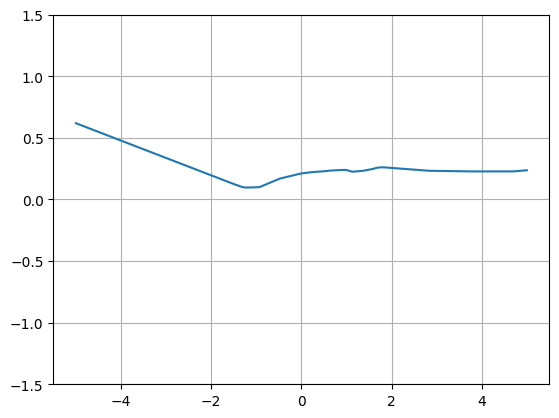

In [9]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# veri
x = torch.linspace(-5, 5, 200).unsqueeze(1)
y_true = torch.sin(x)

# model
model = nn.Sequential(
    nn.Linear(1, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

history = []

epochs = 200  # daha uzun eğitim

# training
for epoch in range(epochs):
    y_pred = model(x)
    loss = loss_fn(y_pred, y_true)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    history.append(y_pred.detach().clone())

# plot
fig, ax = plt.subplots()
line, = ax.plot(x.numpy(), history[0].numpy())

ax.set_ylim(-1.5, 1.5)
ax.grid(True)

def update(i):
    line.set_ydata(history[i].numpy())
    ax.set_title(f"Epoch {i}")
    return line,

ani = FuncAnimation(fig, update, frames=epochs, interval=50)
plt.show()